In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT => temprature
#v => vaccum
#AP => Pressure
#RH => humidity 
#PE => Produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
x = df.drop("PE",axis=1)
y = df["PE"]   # since i am breaking it out  it converts into 1d 
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [7]:
df.shape

(9568, 5)

In [8]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)  # this was the exact  issue and the data leakage was there 

In [9]:
import torch 
import torch.nn as nn

x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype= torch.float32).view(-1,1) #.view => changes dimensions   series -> 2d  
x_test_tensor= torch.tensor(x_test_scaled,dtype= torch.float32)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [10]:
type(x_train_scaled)

numpy.ndarray

In [11]:
type(y_train)

pandas.Series

In [12]:
#data set and data loader 

In [13]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset =  TensorDataset (x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor) 

In [14]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64)

In [15]:
#  Define  ANN  Architecture
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            #1st hidden layer 
            nn.Linear(x_train.shape[1],6),  # zero based indexing (rows, columns)
            # passing all feature as inputs in first layer that is columns
    
            nn.ReLU(),
            # 2nd hidden layer 
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer 
            nn.Linear(6,1)
        )
    def forward(self,x):
        return self.model(x)

In [16]:
import torch.optim as optim 

model = ANN()

#LOSS  optimizer 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())   # calulating weights and biases 

In [17]:
# train
train_losses = []
val_losses =[]
best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss =0.0  # total training loss for 1 epoch

    for xb, yb in train_loader:
        #xb ==> feature  of 1 batch ,
        # yb ==> feature of 1 batch,
        optimizer.zero_grad()
        outputs=model(xb)    # forward  prop 
        loss=criterion(outputs,yb)  # coompute loss
        loss.backward() # backword prop  
        optimizer.step()  # params update 
        
        running_loss += loss.item() #loss is a tensor we are convertimng it to py float 
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad(): # no gradients computed  since we have auto grad in pytorch  so we write this 
        for xb , yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs,yb)
            running_val_loss += loss
            
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/epochs ===> train loss ={epoch_train_loss} & val_loss = {epoch_val_loss}")

    if  epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt") # always  save our model in .pt or .pth

epoch 1/epochs ===> train loss =206682.433984375 & val_loss = 206117.34375
epoch 2/epochs ===> train loss =205356.12565104166 & val_loss = 203723.03125
epoch 3/epochs ===> train loss =200976.230859375 & val_loss = 196898.640625
epoch 4/epochs ===> train loss =191010.79856770832 & val_loss = 183575.8125
epoch 5/epochs ===> train loss =174143.64609375 & val_loss = 163311.234375
epoch 6/epochs ===> train loss =150780.29127604168 & val_loss = 137474.078125
epoch 7/epochs ===> train loss =123227.36380208333 & val_loss = 109095.8359375
epoch 8/epochs ===> train loss =95170.366015625 & val_loss = 82181.40625
epoch 9/epochs ===> train loss =70369.558203125 & val_loss = 60166.9609375
epoch 10/epochs ===> train loss =51502.0427734375 & val_loss = 44505.76171875
epoch 11/epochs ===> train loss =38648.93500976563 & val_loss = 34276.16015625
epoch 12/epochs ===> train loss =30448.16044921875 & val_loss = 27725.935546875
epoch 13/epochs ===> train loss =25169.290152994792 & val_loss = 23339.86914062

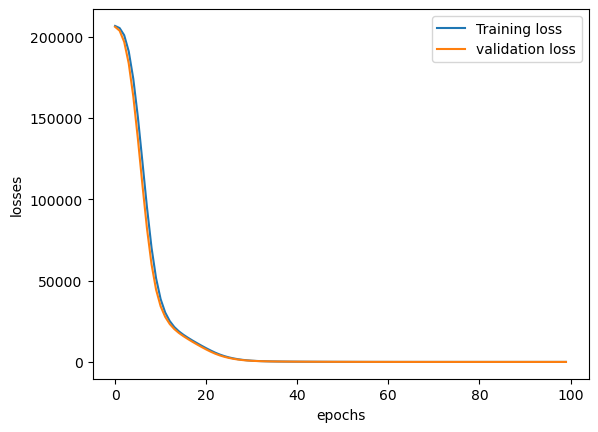

In [18]:
import matplotlib.pyplot as plt 
loss_df = pd.DataFrame({
    "Training loss" :train_losses,
    "validation loss":val_losses}
)
plt.plot(loss_df["Training loss"],label = "Training loss")
plt.plot(loss_df["validation loss"], label ="validation loss" )

plt.xlabel("epochs")
plt.ylabel("losses")
plt.legend()

In [19]:
# loading our best  model 
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [20]:
#  evaluate our model 
model.eval()
with torch.no_grad():
    train_preds=model(x_train_tensor)
    test_preds = model(x_test_tensor )

    train_mse_loss = criterion(train_preds,y_train_tensor)
    test_mse_loss = criterion(test_preds,y_test_tensor)

In [21]:
print("training mse = ", train_mse_loss.item()),
print("test mse = " ,test_mse_loss.item())

training mse =  21.2567081451416
test mse =  20.41084861755371


In [22]:
from sklearn.metrics import r2_score
print("r^2 score =", r2_score(y_test,test_preds))

r^2 score = 0.9286693550764127


In [25]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values "])
actual_df = pd.DataFrame(y_test.values,columns =["Actuall values"])

pd.concat([predicted_df, actual_df], axis=1)


,Predicted Values,Actuall values
0,435.758514,433.27
1,437.143005,438.16
2,461.367462,458.42
3,476.032990,480.82
4,435.890686,441.41
...,...,...
1909,451.366638,456.70
1910,432.012146,438.04
1911,467.719025,467.80
1912,431.449829,437.14
